## **EDA**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:

url = "https://huggingface.co/datasets/jason1966/ahsan81_hotel-reservations-classification-dataset/resolve/main/Hotel%20Reservations.csv"

df = pd.read_csv(url)
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


## 1. Dataset Overview

This section provides an initial overview of the dataset, including its dimensions, columns, data types, and sample records.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 36275
Number of columns: 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         

## 2. Data Quality Check

The dataset was checked for missing values and duplicate records to assess its data quality before performing the exploratory analysis.


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

Total missing values: 0

Duplicate rows: 0


## 3. Descriptive Statistics

Descriptive statistics are used to summarize the numerical variables using measures such as mean, median, standard deviation, minimum, and maximum values.


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


## 4. Booking Status Distribution

The target variable is `booking_status`, which indicates whether a hotel booking was canceled or not canceled.

The distribution of the target variable is examined to understand the class balance.

In [ ]:
status_counts = df["booking_status"].value_counts()

print(status_counts)

print("\nPercentages:")
print(df["booking_status"].value_counts(normalize=True) * 100)

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

Percentages:
booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64


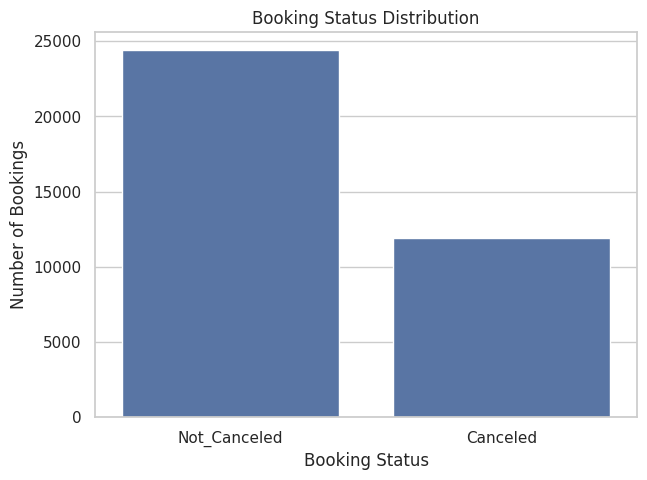

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="booking_status"
)

plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.show()

## 5. Lead Time Analysis

Lead time represents the number of days between the booking date and the arrival date.

The distribution of lead time is analyzed to identify its range and to investigate its relationship with booking cancellation.

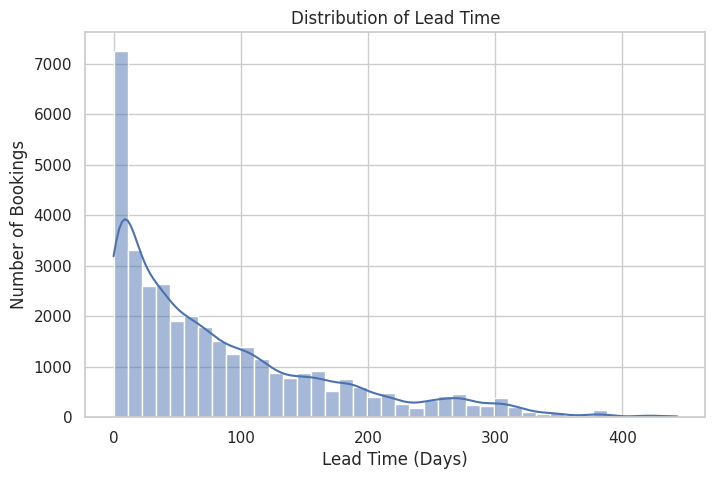

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="lead_time",
    bins=40,
    kde=True
)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")
plt.show()

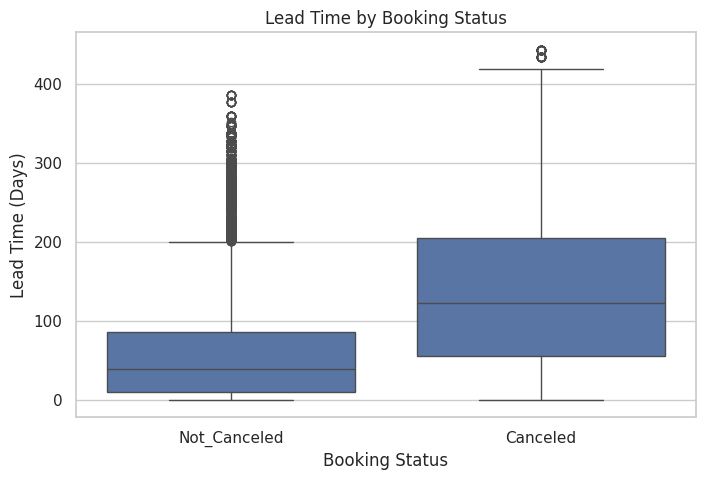

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="booking_status",
    y="lead_time"
)

plt.title("Lead Time by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Lead Time (Days)")
plt.show()

## 6. Average Price per Room Analysis

The average price per room is examined to understand its distribution and its relationship with booking status.

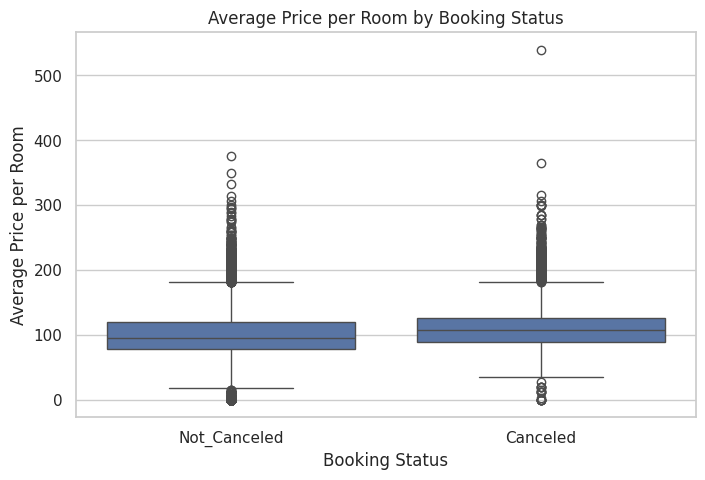

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="booking_status",
    y="avg_price_per_room"
)

plt.title("Average Price per Room by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Price per Room")
plt.show()

## 7. Special Requests Analysis

The number of special requests is analyzed to investigate whether guest requests are associated with booking cancellation.

In [ ]:
special_requests_rate = (
    df.groupby("no_of_special_requests")["booking_status"]
    .apply(lambda x: (x == "Canceled").mean() * 100)
)

print(special_requests_rate)

no_of_special_requests
0    43.206755
1    23.766816
2    14.596700
3     0.000000
4     0.000000
5     0.000000
Name: booking_status, dtype: float64


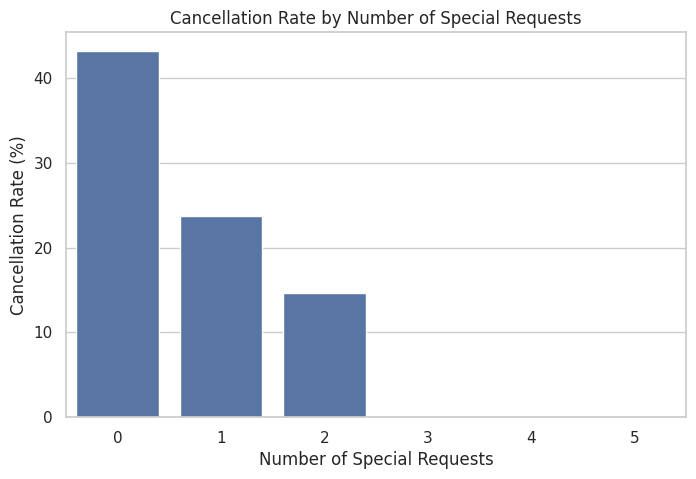

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=special_requests_rate.index,
    y=special_requests_rate.values
)

plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate (%)")
plt.show()

## 8. Market Segment Analysis

The cancellation rate is compared across different market segments to identify potential differences in booking behavior.

In [ ]:
market_cancel_rate = (
    df.groupby("market_segment_type")["booking_status"]
    .apply(lambda x: (x == "Canceled").mean() * 100)
    .sort_values(ascending=False)
)

print(market_cancel_rate)

market_segment_type
Online           36.508142
Offline          29.948708
Aviation         29.600000
Corporate        10.907288
Complementary     0.000000
Name: booking_status, dtype: float64


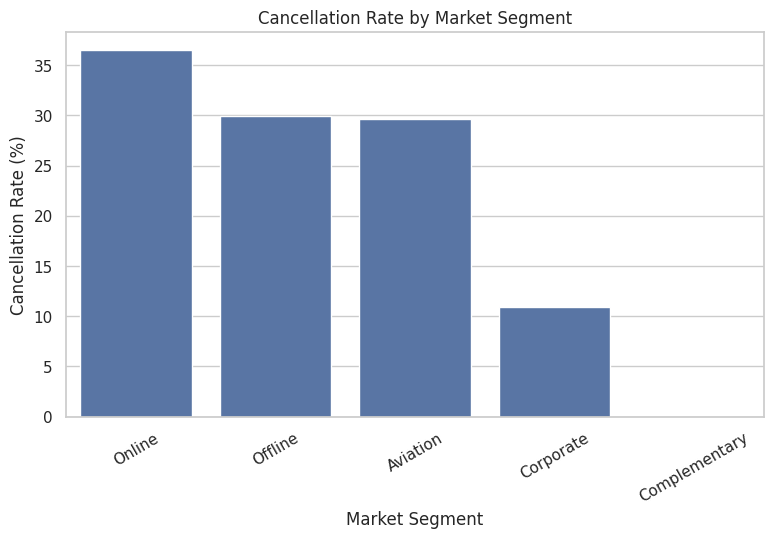

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=market_cancel_rate.index,
    y=market_cancel_rate.values
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=30)
plt.show()

Repeated Guest

In [ ]:
repeated_guest_rate = (
    df.groupby("repeated_guest")["booking_status"]
    .apply(lambda x: (x == "Canceled").mean() * 100)
)

print(repeated_guest_rate)

repeated_guest
0    33.580422
1     1.720430
Name: booking_status, dtype: float64


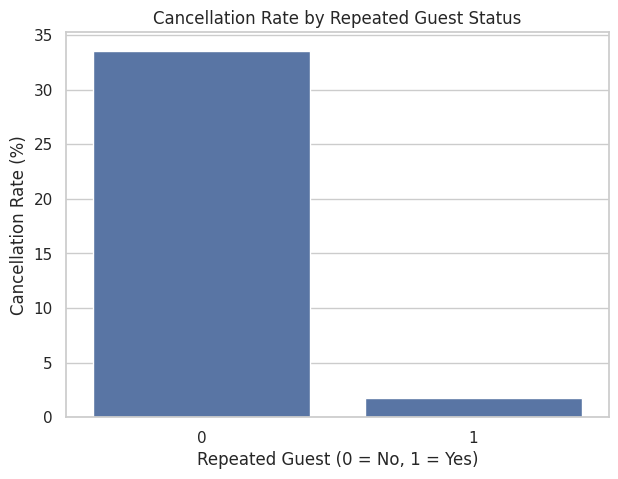

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=repeated_guest_rate.index,
    y=repeated_guest_rate.values
)

plt.title("Cancellation Rate by Repeated Guest Status")
plt.xlabel("Repeated Guest (0 = No, 1 = Yes)")
plt.ylabel("Cancellation Rate (%)")
plt.show()

 Arrival Month Analysis

In [ ]:
monthly_cancel_rate = (
    df.groupby("arrival_month")["booking_status"]
    .apply(lambda x: (x == "Canceled").mean() * 100)
)

print(monthly_cancel_rate)

arrival_month
1      2.366864
2     25.234742
3     29.686175
4     36.366959
5     36.489607
6     40.305963
7     45.000000
8     39.024390
9     33.355021
10    35.358285
11    29.362416
12    13.306852
Name: booking_status, dtype: float64


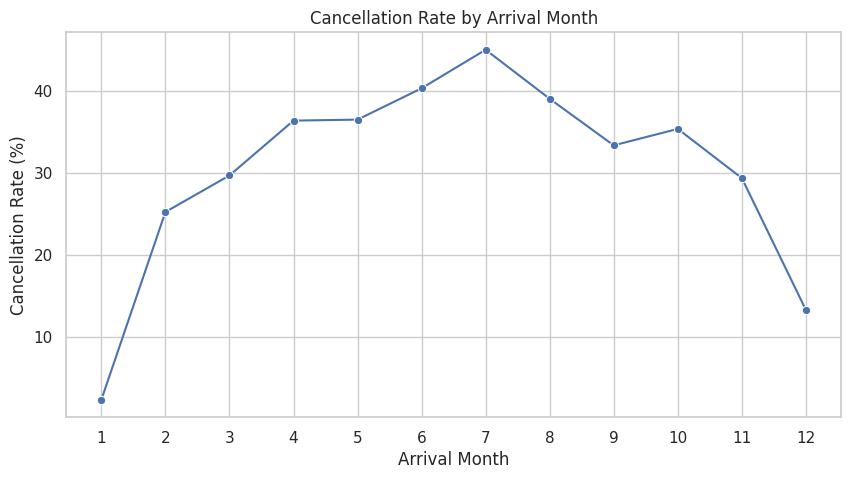

In [ ]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_cancel_rate.index,
    y=monthly_cancel_rate.values,
    marker="o"
)

plt.title("Cancellation Rate by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(range(1, 13))
plt.show()

# Correlation

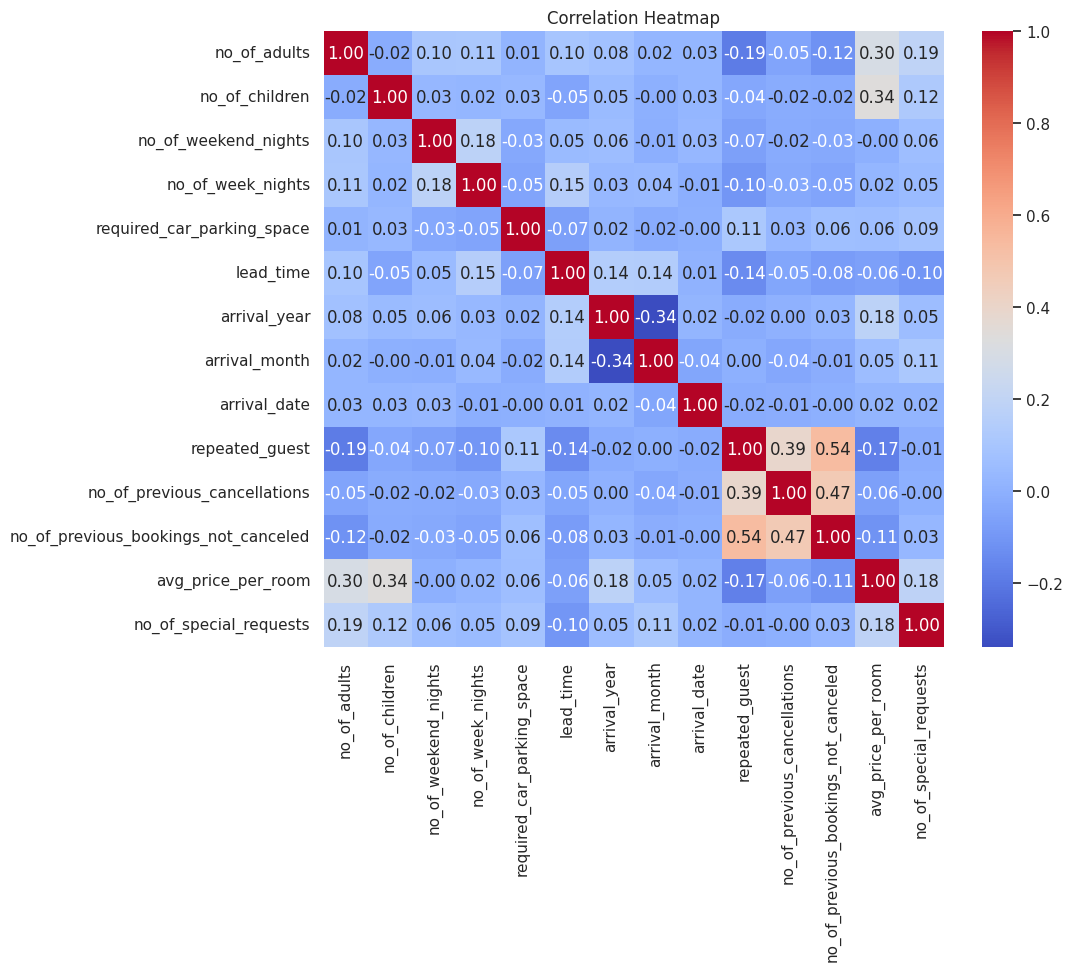

In [ ]:
# heatmap plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='lead_time', ylabel='booking_status'>

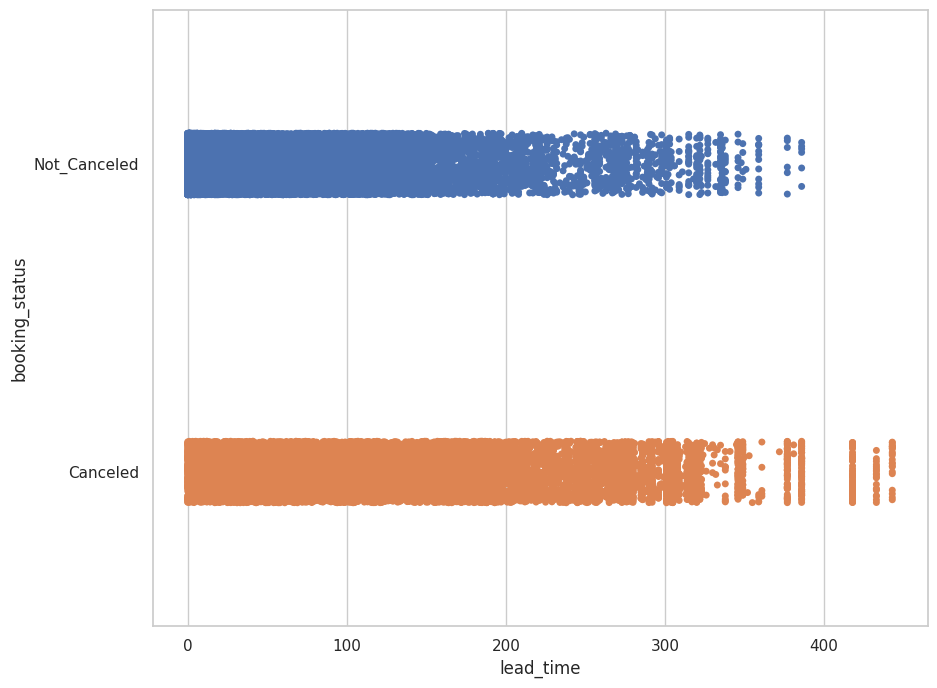

In [ ]:
## dot plot coloring each class
plt.figure(figsize=(10, 8))

sns.stripplot(
    data=df,
    x="lead_time",
    y="booking_status",
    hue="booking_status"
)

## 9. Key Findings

Based on the exploratory data analysis:

1. The dataset contains 36,275 hotel booking records and 19 variables.

2. No missing values or duplicate records were identified.

3. The target variable is moderately imbalanced, with approximately 67.24% Not_Canceled bookings and 32.76% Canceled bookings.

4. Lead time shows the strongest positive numerical association with cancellation. Bookings with longer lead times tend to have higher cancellation rates.

5. The number of special requests has a negative association with cancellation. Bookings with more special requests generally show lower cancellation rates.

6. Cancellation rates vary considerably across market segments.

7. Repeated guests have a substantially lower cancellation rate than non-repeated guests.

8. Cancellation rates also vary across arrival months, indicating potential seasonal patterns.

9. These findings can guide feature selection and model development in the next stage of the project.

# **Data preprocessing**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer

In [ ]:
X = df.drop('booking_status', axis=1)
y = df['booking_status']

# **Drop unimportant columns**

In [ ]:
X = X.drop('Booking_ID', axis=1)


# **Feature Engineering**

In [ ]:
X['total_guests'] = X['no_of_adults'] + X['no_of_children']
X['total_nights'] = ( X['no_of_weekend_nights'] + X['no_of_week_nights'] )
droped_columns=['no_of_adults','no_of_children','no_of_weekend_nights','no_of_week_nights']
X = X.drop(columns=droped_columns)

# **split data**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

# **Encoding**

In [ ]:
y_train = y_train.map({ 'Not_Canceled': 0, 'Canceled': 1 })
y_test = y_test.map({ 'Not_Canceled': 0, 'Canceled': 1 })

In [ ]:
categorical_cols = [ 'type_of_meal_plan', 'room_type_reserved', 'market_segment_type' ]
hot_encoder = OneHotEncoder( handle_unknown='ignore', sparse_output=False )
X_train_encoded = hot_encoder.fit_transform( X_train[categorical_cols] )
X_test_encoded = hot_encoder.transform( X_test[categorical_cols] )

In [ ]:
encoded_columns = hot_encoder.get_feature_names_out( categorical_cols )
X_train_encoded = pd.DataFrame( X_train_encoded, columns=encoded_columns, index=X_train.index )
X_test_encoded = pd.DataFrame( X_test_encoded, columns=encoded_columns, index=X_test.index )

In [ ]:
X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

In [ ]:
X_train = pd.concat( [X_train, X_train_encoded], axis=1 )
X_test = pd.concat( [X_test, X_test_encoded], axis=1 )

# **Handle outliers**

In [ ]:
outlier_columns = ['lead_time','avg_price_per_room','no_of_previous_cancellations',
                   'no_of_previous_bookings_not_canceled'
                   ,'no_of_special_requests','total_guests']


In [ ]:
X_train[outlier_columns].skew()

,0
lead_time,1.302642
avg_price_per_room,0.674572
no_of_previous_cancellations,25.523630
no_of_previous_bookings_not_canceled,19.065551
no_of_special_requests,1.152533
total_guests,0.894121


In [ ]:
pt = PowerTransformer(method='yeo-johnson')
X_train[outlier_columns] = pt.fit_transform(X_train[outlier_columns])
X_test[outlier_columns]=pt.transform(X_test[outlier_columns])

In [ ]:
X_train[outlier_columns].skew()

,0
lead_time,-0.121974
avg_price_per_room,0.268169
no_of_previous_cancellations,10.527309
no_of_previous_bookings_not_canceled,6.413330
no_of_special_requests,0.299752
total_guests,0.008482


no_of_previous_cancellations and no_of_previous_bookings_not_canceled remained highly skewed due to the large proportion of zero values. Since the extreme values may represent valid booking behavior, they were retained without removal or capping.

In [ ]:
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)

# **Data Preprocessing Summary**

The following preprocessing steps were performed before training the machine learning models:

* Checked the dataset for **missing values and duplicate records**; no missing values or duplicates were found.
* Removed the **`Booking_ID`** column because it is an identifier and does not provide useful predictive information.
* Created new features:

  * **`total_guests`** = number of adults + number of children.
  * **`total_nights`** = weekend nights + week nights.
* Removed the original columns used to create these aggregated features.
* Separated the features (`X`) from the target variable (`y`), where **`booking_status`** is the target.
* Split the data into **80% training and 20% testing sets** using stratification to preserve the class distribution.
* Applied **One-Hot Encoding** to the categorical features:

  * `type_of_meal_plan`
  * `room_type_reserved`
  * `market_segment_type`
* Detected and handled outliers using the **IQR method** for selected numerical features:

  * `lead_time`
  * `avg_price_per_room`
  * `no_of_previous_cancellations`
  * `no_of_previous_bookings_not_canceled`
  * `no_of_special_requests`
  * `total_guests`
* Applied **StandardScaler** to standardize the numerical features. The scaler was fitted on the training data and then used to transform both training and testing data.
* The resulting preprocessed data is now ready for **model training and evaluation**.


# **MachineLearning**

# Classical ML

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

**Logistig Regression**

In [ ]:
## model
LR_model = LogisticRegression(max_iter=2000, random_state=42)
LR_model.fit(X_train_scaled, y_train)

LR_pred = LR_model.predict(X_train_scaled)
LR_test = LR_model.predict(X_test_scaled)

In [ ]:
## training metrics
LR_train_accuracy = accuracy_score(y_train, LR_pred)
LR_train_f1 = f1_score(y_train, LR_pred)
LR_train_recall = recall_score(y_train, LR_pred)
LR_train_precesion = precision_score(y_train, LR_pred)

print("Training Accuracy:", LR_train_accuracy)
print("Training F1 Score:", LR_train_f1)
print(classification_report(y_train, LR_pred))

Training Accuracy: 0.8078566505858029
Training F1 Score: 0.6835773464986948
              precision    recall  f1-score   support

           0       0.83      0.89      0.86     19512
           1       0.74      0.63      0.68      9508

    accuracy                           0.81     29020
   macro avg       0.79      0.76      0.77     29020
weighted avg       0.80      0.81      0.80     29020



In [ ]:
## testing metrics
LR_test_accuracy = accuracy_score(y_test, LR_test)
LR_test_f1 = f1_score(y_test, LR_test)
LR_test_recall = recall_score(y_test, LR_test)
LR_test_precesion = precision_score(y_test, LR_test)

print("Testing Accuracy:", LR_test_accuracy)
print("Testing F1 Score:", LR_test_f1)
print(classification_report(y_test, LR_test))

Testing Accuracy: 0.8139214334941419
Testing F1 Score: 0.6920620437956204
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4878
           1       0.76      0.64      0.69      2377

    accuracy                           0.81      7255
   macro avg       0.80      0.77      0.78      7255
weighted avg       0.81      0.81      0.81      7255



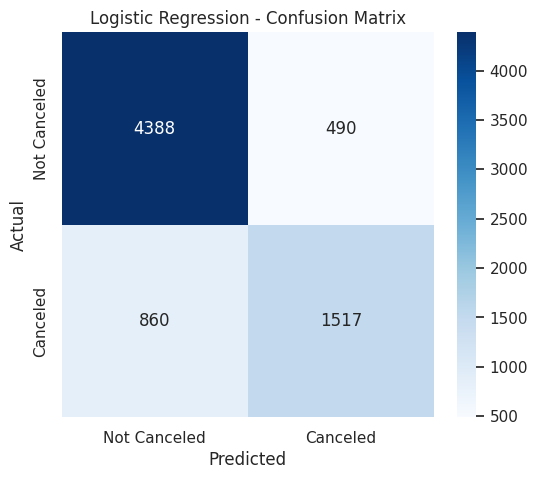

In [ ]:
## confusion matrix
LR_cm = confusion_matrix(y_test, LR_test)
plt.figure(figsize=(6, 5))

sns.heatmap(
    LR_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Canceled', 'Canceled'],
    yticklabels=['Not Canceled', 'Canceled']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

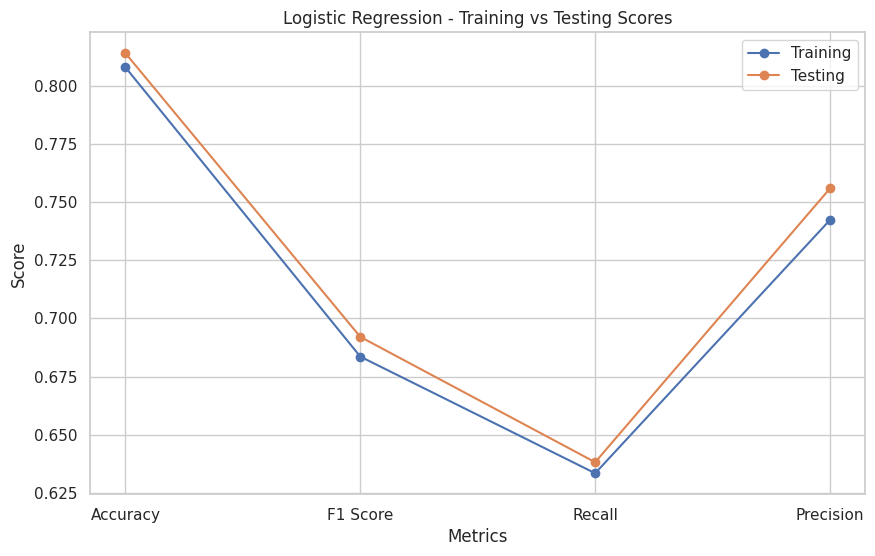

In [ ]:
## trainig Vs testing
LR_train_scores = [LR_train_accuracy, LR_train_f1, LR_train_recall, LR_train_precesion]
LR_test_scores = [LR_test_accuracy, LR_test_f1, LR_test_recall, LR_test_precesion]
metrics = ['Accuracy', 'F1 Score', 'Recall', 'Precision']

plt.figure(figsize=(10, 6))
plt.plot(metrics, LR_train_scores, marker='o', label='Training')
plt.plot(metrics, LR_test_scores, marker='o', label='Testing')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Logistic Regression - Training vs Testing Scores')
plt.legend()
plt.show()

**LR PERFORMANCE ->** trainig and testing accuracy are very close indicating good generalization, However, the recall for caceled bookings was 65%, meaning that the model failed to identify a considirable portin of actual cancellations.

**Unpruned Decsion Tree**

In [ ]:
## model
DT_model = DecisionTreeClassifier(random_state=42)
DT_model.fit(X_train, y_train)

DT_pred = DT_model.predict(X_train)
DT_test = DT_model.predict(X_test)

In [ ]:
## trainig metrics
DT_train_accuracy = accuracy_score(y_train, DT_pred)
DT_train_f1 = f1_score(y_train, DT_pred)
DT_train_recall = recall_score(y_train, DT_pred)
DT_train_precesion = precision_score(y_train, DT_pred)

print("Training Accuracy:", DT_train_accuracy)
print("Training F1 Score:", DT_train_f1)
print(classification_report(y_train, DT_pred))

Training Accuracy: 0.9941764300482426
Training F1 Score: 0.9910822647881379
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     19512
           1       0.99      0.99      0.99      9508

    accuracy                           0.99     29020
   macro avg       0.99      0.99      0.99     29020
weighted avg       0.99      0.99      0.99     29020



In [ ]:
## testing metrics
DT_test_accuracy = accuracy_score(y_test, DT_test)
DT_test_f1 = f1_score(y_test, DT_test)
DT_test_recall = recall_score(y_test, DT_test)
DT_test_precesion = precision_score(y_test, DT_test)

print("Testing Accuracy:", DT_test_accuracy)
print("Testing F1 Score:", DT_test_f1)
print(classification_report(y_test, DT_test))

Testing Accuracy: 0.8733287388008271
Testing F1 Score: 0.8097702339060237
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      4878
           1       0.80      0.82      0.81      2377

    accuracy                           0.87      7255
   macro avg       0.85      0.86      0.86      7255
weighted avg       0.87      0.87      0.87      7255



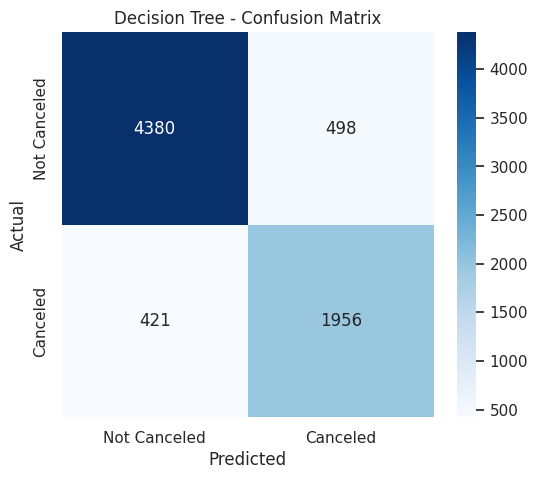

In [ ]:
## confusion matrix
DT_cm = confusion_matrix(y_test, DT_test)
plt.figure(figsize=(6, 5))

sns.heatmap(
    DT_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Canceled', 'Canceled'],
    yticklabels=['Not Canceled', 'Canceled']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()


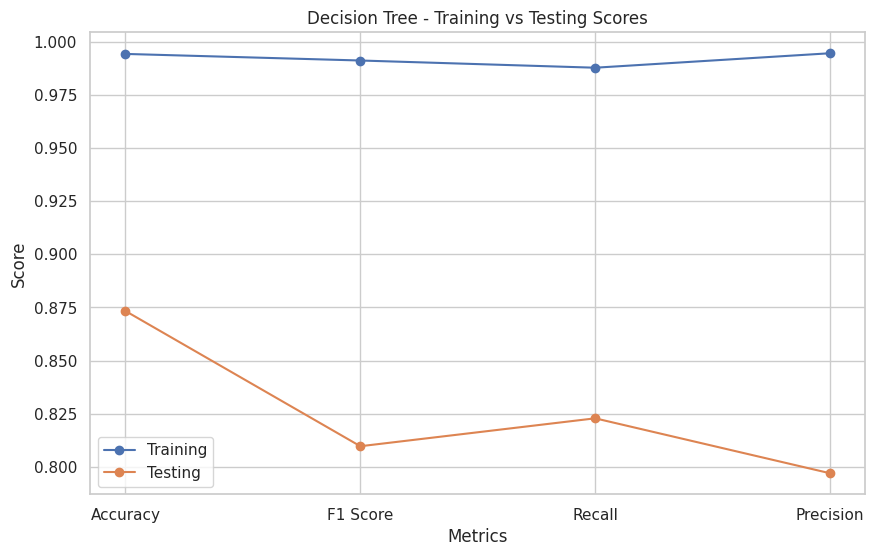

In [ ]:
DT_train_scores = [DT_train_accuracy, DT_train_f1, DT_train_recall, DT_train_precesion]
DT_test_scores = [DT_test_accuracy, DT_test_f1, DT_test_recall, DT_test_precesion]

plt.figure(figsize=(10, 6))
plt.plot(metrics, DT_train_scores, marker='o', label='Training')
plt.plot(metrics, DT_test_scores, marker='o', label='Testing')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Decision Tree - Training vs Testing Scores')
plt.legend()
plt.show()

**Unpruned Deciosion Tree ->** trainig accuracy is extremerly higher than testing accuracy indicating **Strong overfitting**. Despiting the overfitting, the model performed better than LR on the testing data with a 81% recall and 80% precision.

**Pruned Deciosion Tree**

In [ ]:
## Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)


Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1 Score: 0.7960249666208856


In [ ]:
## model
Pruned_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_leaf=1,
    min_samples_split=10)
Pruned_model.fit(X_train, y_train)

Pruned_pred = Pruned_model.predict(X_train)
Pruned_test = Pruned_model.predict(X_test)

In [ ]:
## train metrics
Pruned_train_accuracy = accuracy_score(y_train, Pruned_pred)
Pruned_train_f1 = f1_score(y_train, Pruned_pred)
Pruned_train_recall = recall_score(y_train, Pruned_pred)
Pruned_train_precesion = precision_score(y_train, Pruned_pred)

print("Training Accuracy:", Pruned_train_accuracy)
print("Training F1 Score:", Pruned_train_f1)
print(classification_report(y_train, Pruned_pred))

Training Accuracy: 0.9115782219159201
Training F1 Score: 0.8608610779741893
              precision    recall  f1-score   support

           0       0.92      0.95      0.94     19512
           1       0.89      0.83      0.86      9508

    accuracy                           0.91     29020
   macro avg       0.91      0.89      0.90     29020
weighted avg       0.91      0.91      0.91     29020



In [ ]:
## test metrics
Pruned_test_accuracy = accuracy_score(y_test, Pruned_test)
Pruned_test_f1 = f1_score(y_test, Pruned_test)
Pruned_test_recall = recall_score(y_test, Pruned_test)
Pruned_test_precesion = precision_score(y_test, Pruned_test)

print("Testing Accuracy:", Pruned_test_accuracy)
print("Testing F1 Score:", Pruned_test_f1)
print(classification_report(y_test, Pruned_test))

Testing Accuracy: 0.8851826326671262
Testing F1 Score: 0.8195798137318605
              precision    recall  f1-score   support

           0       0.90      0.93      0.92      4878
           1       0.84      0.80      0.82      2377

    accuracy                           0.89      7255
   macro avg       0.87      0.86      0.87      7255
weighted avg       0.88      0.89      0.88      7255



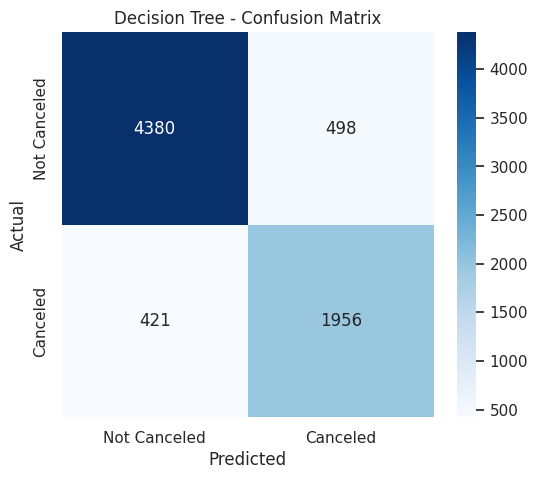

In [ ]:
## confusion matrix
Pruned_cm = confusion_matrix(y_test, Pruned_test)
plt.figure(figsize=(6, 5))

sns.heatmap(
    DT_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Canceled', 'Canceled'],
    yticklabels=['Not Canceled', 'Canceled']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()


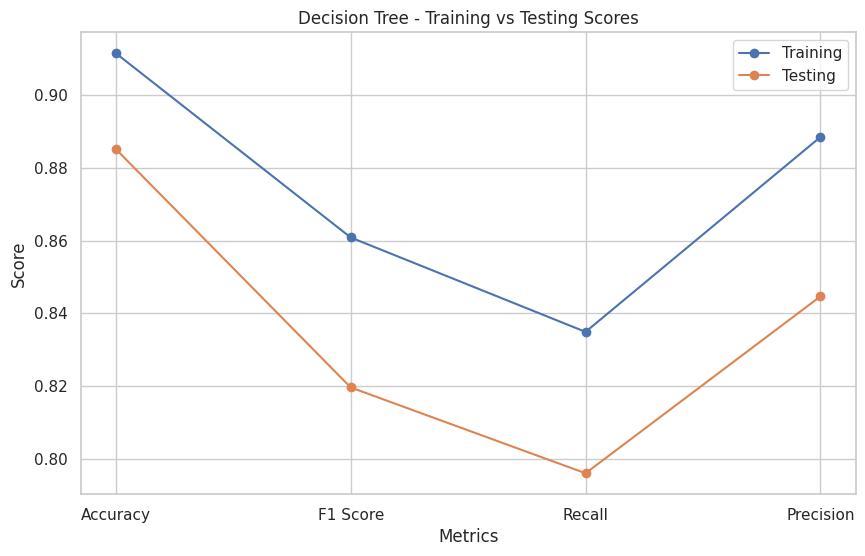

In [ ]:
## train VS test
Pruned_train_scores = [Pruned_train_accuracy, Pruned_train_f1, Pruned_train_recall, Pruned_train_precesion]
Pruned_test_scores = [Pruned_test_accuracy, Pruned_test_f1, Pruned_test_recall, Pruned_test_precesion]

plt.figure(figsize=(10, 6))
plt.plot(metrics, Pruned_train_scores, marker='o', label='Training')
plt.plot(metrics, Pruned_test_scores, marker='o', label='Testing')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Decision Tree - Training vs Testing Scores')
plt.legend()
plt.show()

**Pruned Decision Tree ->** trainig and testing accuracy are much closer that unpruned DT indicating that **overfitting has been significantly reduced**. this model achieved 78% recall and 85% precesion on testing data for canceled bookings showing better generalization.

# Ensemble ML

**KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
KNN_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='euclidean'
)

KNN_model.fit(X_train_scaled, y_train)

KNN_pred = KNN_model.predict(X_train_scaled)
KNN_test = KNN_model.predict(X_test_scaled)

In [ ]:
KNN_test_accuracy = accuracy_score(y_test, KNN_test)
KNN_test_f1 = f1_score(y_test, KNN_test)
KNN_test_recall = recall_score(y_test, KNN_test)
KNN_test_precesion = precision_score(y_test, KNN_test)

print("KNN Test Accuracy:", KNN_test_accuracy)
print("KNN Test F1 Score:", KNN_test_f1)
print("KNN Test Recall:", KNN_test_recall)
print("KNN Test Precision:", KNN_test_precesion)

KNN Test Accuracy: 0.8713990351481736
KNN Test F1 Score: 0.7998283630122291
KNN Test Recall: 0.7841817416912074
KNN Test Precision: 0.8161120840630472


**Random Forest**

In [ ]:
## model
from sklearn.ensemble import RandomForestClassifier

RF_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

RF_model.fit(X_train, y_train)

RF_pred = RF_model.predict(X_train)
RF_test = RF_model.predict(X_test)

In [ ]:
## training metrics
RF_train_accuracy = accuracy_score(y_train, RF_pred)
RF_train_f1 = f1_score(y_train, RF_pred)
RF_train_recall = recall_score(y_train, RF_pred)
RF_train_precesion = precision_score(y_train, RF_pred)

print("Training Accuracy:", RF_train_accuracy)
print("Training F1 Score:", RF_train_f1)
print(classification_report(y_train, RF_pred))


Training Accuracy: 0.9940385940730531
Training F1 Score: 0.9909076575392862
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19512
           1       0.99      0.99      0.99      9508

    accuracy                           0.99     29020
   macro avg       0.99      0.99      0.99     29020
weighted avg       0.99      0.99      0.99     29020



In [ ]:
## testing metrics
RF_test_accuracy = accuracy_score(y_test, RF_test)
RF_test_f1 = f1_score(y_test, RF_test)
RF_test_recall = recall_score(y_test, RF_test)
RF_test_precesion = precision_score(y_test, RF_test)

print("Testing Accuracy:", RF_test_accuracy)
print("Testing F1 Score:", RF_test_f1)
print(classification_report(y_test, RF_test))

Testing Accuracy: 0.9039283252929015
Testing F1 Score: 0.8479825517993457
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      4878
           1       0.88      0.82      0.85      2377

    accuracy                           0.90      7255
   macro avg       0.90      0.88      0.89      7255
weighted avg       0.90      0.90      0.90      7255



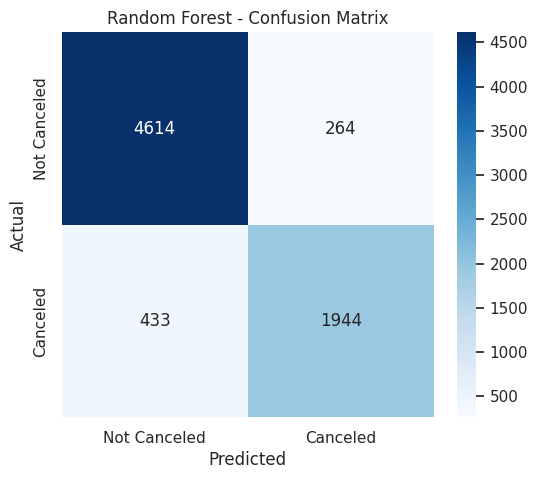

In [ ]:
## confusion matrix
RF_cm = confusion_matrix(y_test, RF_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    RF_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Canceled', 'Canceled'],
    yticklabels=['Not Canceled', 'Canceled']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

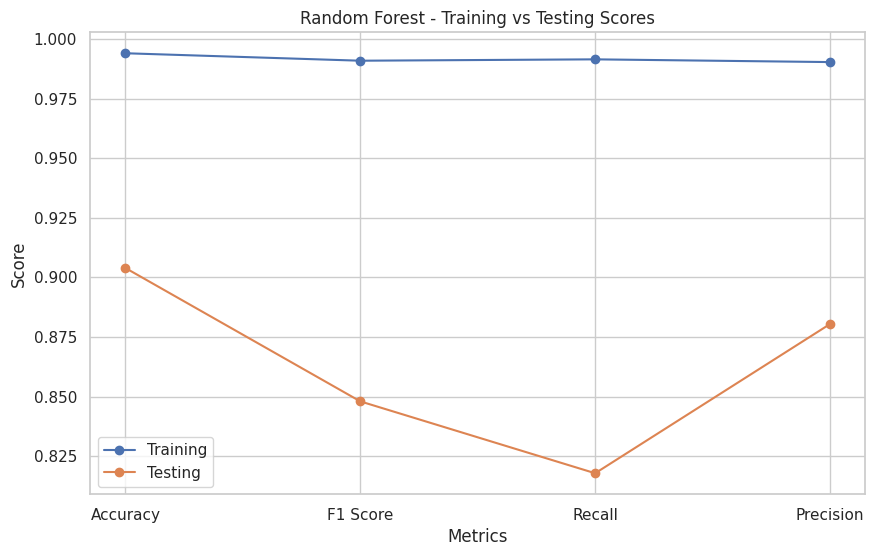

In [ ]:
## trainig Vs testing
RF_train_scores = [
    RF_train_accuracy,
    RF_train_f1,
    RF_train_recall,
    RF_train_precesion
]

RF_test_scores = [
    RF_test_accuracy,
    RF_test_f1,
    RF_test_recall,
    RF_test_precesion
]

plt.figure(figsize=(10, 6))
plt.plot(metrics, RF_train_scores, marker='o', label='Training')
plt.plot(metrics, RF_test_scores, marker='o', label='Testing')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Random Forest - Training vs Testing Scores')
plt.legend()
plt.show()

**Random Forest ->** The model combines multiple decision trees to improve prediction performance and reduce the overfitting problem of a single decision tree. The training and testing scores are compared to evaluate the model's generalization.

# **Model Comparison**

In [ ]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Unpruned Decision Tree',
        'Pruned Decision Tree',
        'Random Forest',
        'KNN'
    ],

    'Accuracy': [
        LR_test_accuracy,
        DT_test_accuracy,
        Pruned_test_accuracy,
        RF_test_accuracy,
        KNN_test_accuracy
    ],

    'F1 Score': [
        LR_test_f1,
        DT_test_f1,
        Pruned_test_f1,
        RF_test_f1,
        KNN_test_f1
    ],

    'Recall': [
        LR_test_recall,
        DT_test_recall,
        Pruned_test_recall,
        RF_test_recall,
        KNN_test_recall
    ],

    'Precision': [
        LR_test_precesion,
        DT_test_precesion,
        Pruned_test_precesion,
        RF_test_precesion,
        KNN_test_precesion
    ]
})

model_results

,Model,Accuracy,F1 Score,Recall,Precision
0,Logistic Regression,0.813921,0.692062,0.638199,0.755855
1,Unpruned Decision Tree,0.873329,0.809770,0.822886,0.797066
2,Pruned Decision Tree,0.885183,0.819580,0.795961,0.844643
3,Random Forest,0.903928,0.847983,0.817838,0.880435
4,KNN,0.871399,0.799828,0.784182,0.816112


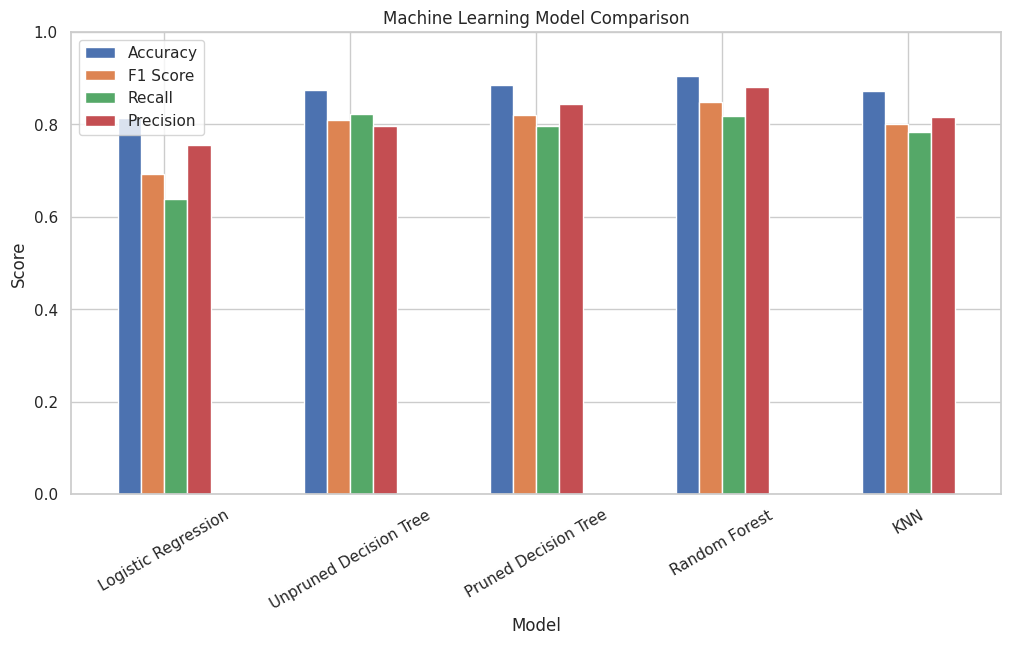

In [ ]:
model_results.set_index('Model')[
    ['Accuracy', 'F1 Score', 'Recall', 'Precision']
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Machine Learning Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend()
plt.show()

## Model Comparison Findings

The models were compared using Accuracy, F1 Score, Recall, and Precision on the testing data.

Since the dataset contains both canceled and non-canceled bookings, accuracy alone is not sufficient to determine the best model. F1 Score provides a balance between precision and recall, while recall is particularly important because it measures how many actual canceled bookings were correctly identified.

The model with the strongest overall testing performance will be selected for further hyperparameter optimization.

**Random Forest Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
## Grid Search

rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

RF_grid = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

RF_grid_search = GridSearchCV(
    estimator=RF_grid,
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

RF_grid_search.fit(X_train, y_train)

print("Best Parameters:", RF_grid_search.best_params_)
print("Best CV F1 Score:", RF_grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 Score: 0.8182580641832093


In [ ]:
## best model


Best_RF_model = RF_grid_search.best_estimator_

Best_RF_pred = Best_RF_model.predict(X_train)
Best_RF_test = Best_RF_model.predict(X_test)


In [ ]:
## training metrics

Best_RF_train_accuracy = accuracy_score(y_train, Best_RF_pred)
Best_RF_train_f1 = f1_score(y_train, Best_RF_pred)
Best_RF_train_recall = recall_score(y_train, Best_RF_pred)
Best_RF_train_precesion = precision_score(y_train, Best_RF_pred)

print("Training Accuracy:", Best_RF_train_accuracy)
print("Training F1 Score:", Best_RF_train_f1)
print(classification_report(y_train, Best_RF_pred))

Training Accuracy: 0.9099931082012406
Training F1 Score: 0.8570803239220836
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     19512
           1       0.89      0.82      0.86      9508

    accuracy                           0.91     29020
   macro avg       0.91      0.89      0.90     29020
weighted avg       0.91      0.91      0.91     29020



In [ ]:
## testing metrics

Best_RF_test_accuracy = accuracy_score(y_test, Best_RF_test)
Best_RF_test_f1 = f1_score(y_test, Best_RF_test)
Best_RF_test_recall = recall_score(y_test, Best_RF_test)
Best_RF_test_precesion = precision_score(y_test, Best_RF_test)

print("Testing Accuracy:", Best_RF_test_accuracy)
print("Testing F1 Score:", Best_RF_test_f1)
print(classification_report(y_test, Best_RF_test))


Testing Accuracy: 0.8940041350792557
Testing F1 Score: 0.829754261678105
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      4878
           1       0.88      0.79      0.83      2377

    accuracy                           0.89      7255
   macro avg       0.89      0.87      0.88      7255
weighted avg       0.89      0.89      0.89      7255



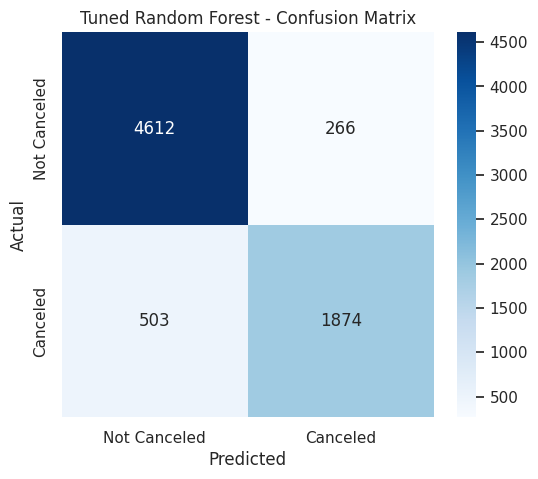

In [ ]:
## confusion matrix

Best_RF_cm = confusion_matrix(y_test, Best_RF_test)

plt.figure(figsize=(6, 5))

sns.heatmap(
    Best_RF_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Canceled', 'Canceled'],
    yticklabels=['Not Canceled', 'Canceled']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Random Forest - Confusion Matrix')
plt.show()


**Random Forest After & Before Tuning**

Random Forest Before vs After Tuning


,Metric,Before Tuning,After Tuning
0,Accuracy,0.903928,0.894004
1,F1 Score,0.847983,0.829754
2,Recall,0.817838,0.788389
3,Precision,0.880435,0.875701


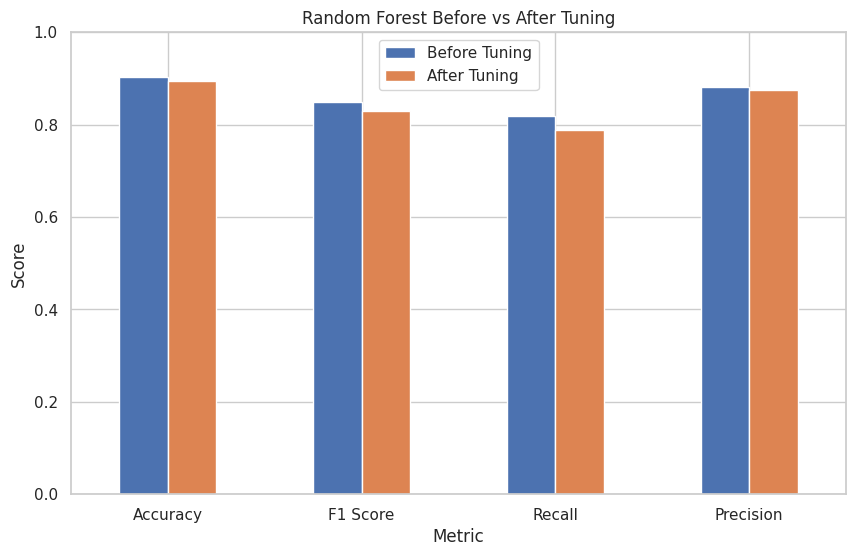

In [ ]:
RF_comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'F1 Score',
        'Recall',
        'Precision'
    ],

    'Before Tuning': [
        RF_test_accuracy,
        RF_test_f1,
        RF_test_recall,
        RF_test_precesion
    ],

    'After Tuning': [
        Best_RF_test_accuracy,
        Best_RF_test_f1,
        Best_RF_test_recall,
        Best_RF_test_precesion
    ]
})

print("Random Forest Before vs After Tuning")
display(RF_comparison)


RF_comparison.set_index('Metric').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Random Forest Before vs After Tuning')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()


**Random Forest Tuning ->** GridSearchCV was used with 5-fold cross-validation to find the combination of hyperparameters that achieved the highest F1 Score. The tuned model was then evaluated on the testing data and compared with the original Random Forest model.

## Feature Importance

Top 15 Important Features


,Feature,Importance
1,lead_time,0.353148
9,no_of_special_requests,0.145998
8,avg_price_per_room,0.132980
3,arrival_month,0.072420
4,arrival_date,0.055057
11,total_nights,0.048752
27,market_segment_type_Online,0.039193
2,arrival_year,0.035753
10,total_guests,0.027478
26,market_segment_type_Offline,0.024596


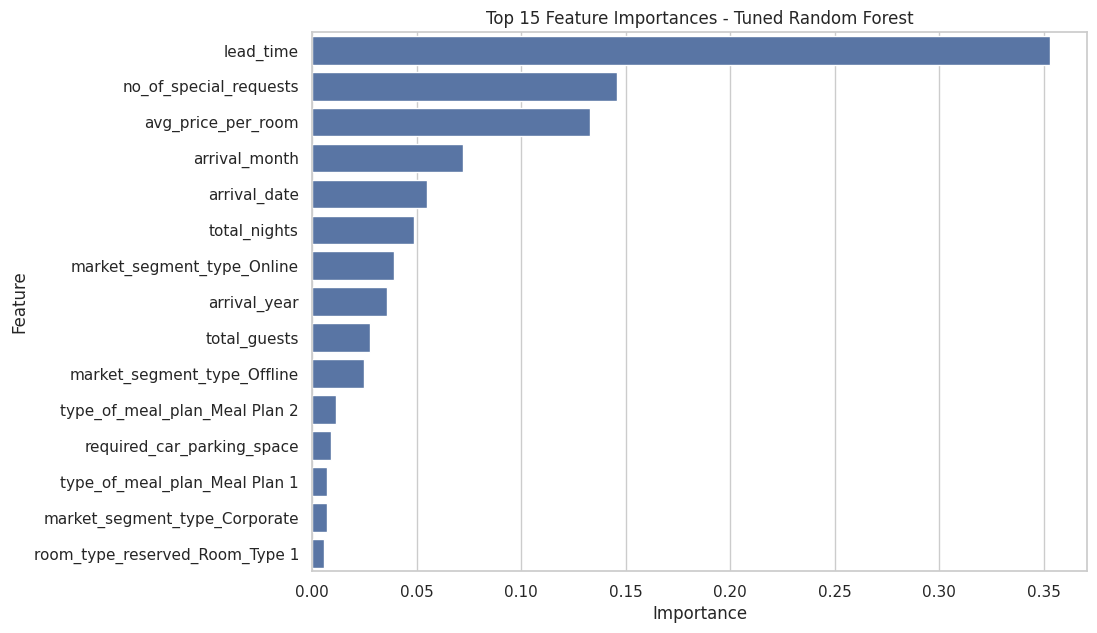

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': Best_RF_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Important Features")
display(feature_importance.head(15))


## visualization
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Feature Importances - Tuned Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


## Feature Importance Findings

Feature importance shows which variables contributed most to the predictions made by the Random Forest model.

The most important features can be compared with the findings from the EDA to determine whether the machine learning model supports the relationships observed during the exploratory analysis.

In [ ]:
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Unpruned Decision Tree',
        'Pruned Decision Tree',
        'Random Forest',
        'Tuned Random Forest',
        'KNN'
    ],

    'Accuracy': [
        LR_test_accuracy,
        DT_test_accuracy,
        Pruned_test_accuracy,
        RF_test_accuracy,
        Best_RF_test_accuracy,
        KNN_test_accuracy
    ],

    'F1 Score': [
        LR_test_f1,
        DT_test_f1,
        Pruned_test_f1,
        RF_test_f1,
        Best_RF_test_f1,
        KNN_test_f1
    ],

    'Recall': [
        LR_test_recall,
        DT_test_recall,
        Pruned_test_recall,
        RF_test_recall,
        Best_RF_test_recall,
        KNN_test_recall
    ],

    'Precision': [
        LR_test_precesion,
        DT_test_precesion,
        Pruned_test_precesion,
        RF_test_precesion,
        Best_RF_test_precesion,
        KNN_test_precesion
    ]
})

final_results.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,F1 Score,Recall,Precision
3,Random Forest,0.903928,0.847983,0.817838,0.880435
4,Tuned Random Forest,0.894004,0.829754,0.788389,0.875701
2,Pruned Decision Tree,0.884080,0.818398,0.797223,0.840728
1,Unpruned Decision Tree,0.873329,0.809770,0.822886,0.797066
5,KNN,0.871399,0.799828,0.784182,0.816112
0,Logistic Regression,0.813921,0.692062,0.638199,0.755855


# **Final Model**

In [ ]:
best_model_name = final_results.loc[
    final_results['F1 Score'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)
print(
    "Best F1 Score:",
    final_results['F1 Score'].max()
)

Best Model: Random Forest
Best F1 Score: 0.8479825517993457


## Final Model Findings

The final model was selected based on its testing F1 Score because the project focuses on identifying canceled hotel bookings while maintaining a balance between precision and recall.

The selected model provides the strongest overall performance among the evaluated models and can therefore be used to predict whether a new hotel reservation is likely to be canceled.